# 03 — Model Training and Evaluation

Notebook 03 dibuat sebagai **modelling-only notebook**.

Isi notebook ini:

1. Train dan evaluasi model regresi `FloodProbability`.
2. Train dan evaluasi model klasifikasi `vulnerability_label` dari Method 3.
3. Export prediction artifacts untuk Notebook 04 dan 05.

Notebook ini **tidak** melakukan stress test dan **tidak** membuat final priority matrix.  
Metode 5 dipindahkan ke Notebook 04, sedangkan Metode 1 dipindahkan ke Notebook 05.

Model zoo tetap lengkap. Notebook ini mengevaluasi model linear, tree ensemble, histogram boosting, serta optional boosters **XGBoost, LightGBM, dan CatBoost** jika package tersedia. Boosting model tidak dipindahkan ke Notebook 04/05 karena boosting tetap bagian dari modelling utama di Notebook 03.

In [1]:
from pathlib import Path
import os, json, warnings, importlib.util
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor,
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
import joblib

# Keep the complete model zoo. Optional boosters are included when installed.
# Set to False only when the runtime is too limited.
RUN_OPTIONAL_BOOSTERS = True

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
MODEL_DIR = PROJECT_ROOT / 'models'
for p in [OUTPUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 180,
    'font.size': 10, 'axes.titlesize': 13, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .22, 'legend.frameon': False
})
COLORS = {'blue':'#2F80ED', 'navy':'#243B53', 'orange':'#F2994A', 'red':'#D64545', 'green':'#27AE60', 'purple':'#7B61FF', 'gray':'#6B7280'}

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('saved:', path)

def make_onehot():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mode_or_unknown(s):
    s = s.dropna()
    return 'Unknown' if s.empty else s.value_counts().idxmax()

def optional_import(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None

class LabelEncodedClassifier(BaseEstimator, ClassifierMixin):
    """Wrap classifiers that require integer class labels, then expose original labels."""
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_enc = self.label_encoder_.fit_transform(y)
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y_enc)
        self.classes_ = self.label_encoder_.classes_
        return self

    def predict(self, X):
        pred_enc = self.estimator_.predict(X)
        pred_enc = np.asarray(pred_enc, dtype=int).reshape(-1)
        return self.label_encoder_.inverse_transform(pred_enc)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


## 1. Load Notebook 02 outputs

In [2]:
required = ['02_flood_modeling_dataset.csv', '02_rice_vulnerability_dataset.csv']
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Run Notebook 01 and 02 first. Missing: {missing}')

flood_df = pd.read_csv(OUTPUT_DIR / '02_flood_modeling_dataset.csv')
rice_df = pd.read_csv(OUTPUT_DIR / '02_rice_vulnerability_dataset.csv')

metadata_path = OUTPUT_DIR / '02_preprocessing_metadata.json'
metadata = json.load(open(metadata_path)) if metadata_path.exists() else {}

TARGET_FLOOD = metadata.get('target_flood', 'FloodProbability')
RICE_TARGET = metadata.get('rice_target', 'vulnerability_label')
LABEL_ORDER = metadata.get('label_order', ['Low Vulnerability', 'Medium Vulnerability', 'High Vulnerability'])

flood_exclude = {TARGET_FLOOD, 'flood_risk_label', 'high_flood_risk_flag', 'total_pressure_score'}
FLOOD_FEATURES = metadata.get('flood_features', [])
# Keep only numeric predictors for regression. Some intermediate files may also contain
# categorical risk labels; those are excluded to avoid target leakage and preprocessing errors.
FLOOD_FEATURES = [
    c for c in FLOOD_FEATURES
    if c in flood_df.columns and c not in flood_exclude and pd.api.types.is_numeric_dtype(flood_df[c])
]
if not FLOOD_FEATURES:
    FLOOD_FEATURES = [c for c in flood_df.columns if c not in flood_exclude and pd.api.types.is_numeric_dtype(flood_df[c])]

print('Flood dataset:', flood_df.shape, '| target:', TARGET_FLOOD, '| features:', len(FLOOD_FEATURES))
print('Rice dataset :', rice_df.shape, '| target:', RICE_TARGET)
display(flood_df.head(2))
display(rice_df.head(2))

Flood dataset: (50000, 28) | target: FloodProbability | features: 20
Rice dataset : (787, 65) | target: vulnerability_label


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability,Climate & natural pressure,Land-use pressure,Hydraulic infrastructure,Governance & preparedness,total_pressure_score,flood_risk_label,high_flood_risk_flag
0,3.0,8.0,6.0,6.0,4.0,4.0,6.0,2.0,3.0,2.0,5.0,10.0,7.0,4.0,2.0,3.0,4.0,3.0,2.0,6.0,0.450,4.428571,3.8,5.4,4.333333,4.490476,Low Flood Risk,0
1,8.0,4.0,5.0,7.0,7.0,9.0,1.0,5.0,5.0,4.0,6.0,9.0,2.0,6.0,2.0,1.0,1.0,9.0,1.0,3.0,0.475,5.714286,4.8,4.2,3.333333,4.511905,Low Flood Risk,0


,actor,region,dmu,actor_role,vulnerability_label,final_vulnerability_score,label_source,labeling_function_hits,label_reason,total_cost,output_value,margin,rc_ratio,cost_revenue_ratio,operational_burden_ratio,precipitation_stress_raw,rule_vulnerability_score,cluster_support_score,cluster_support_label,rule_cluster_agreement,cluster_support_gap,vulnerability_cluster,lf_below_break_even,lf_negative_margin,lf_high_composite_pressure,lf_thin_rc_buffer,lf_thin_margin_buffer,lf_medium_composite_pressure,source_sheet,source_row,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,number_of_machines,value_of_milled_grains_idr,amount_of_milled_rice_kg,supporting_equipment_cost_idr,nilaiberashasilgiling,total_revenue_of_milling_machine_idr,total_rice_purchase_kg,total_rice_purchase_idr,building_rent_cost_idr,value_of_rice_sold_idr,total_precipitation_pct,precipitation_quality_pct,value_of_rice_purchase_idr,operational_cost,quantity_proxy,margin_ratio,cost_per_quantity_proxy,output_per_quantity_proxy,negative_margin_flag,below_break_even_flag,financial_infeasibility_score,margin_pressure_score,operational_burden_score,frontier_efficiency_score,frontier_inefficiency_score,precipitation_stress_score,low_utilization_pressure
0,Farmer,Garut,1,upstream production,Low Vulnerability,0.287454,default_positive_buffer,positive buffer,Far from actor frontier,11418000.0,16200000.0,4782000.0,1.418812,0.704815,0.417901,NaN,0.287454,0.0,Low Vulnerability,True,0.287454,0,0,0,0,0,0,0,Farmer Data,2,2800.0,4900000.0,1400000.0,644000.0,3640000.0,364000.0,470000.0,16200000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6770000.0,2800.0,0.295185,4077.857143,5785.714286,0,0,0.1,0.15,0.234256,0.16612,0.83388,0.5,0.928558
1,Farmer,Garut,2,upstream production,High Vulnerability,0.847148,hard_rule_below_break_even,R/C < 1; negative margin; high composite pressure,R/C < 1: below break-even; Negative margin; Fa...,8264000.0,8100000.0,-164000.0,0.980155,1.020247,0.733333,NaN,0.847148,1.0,High Vulnerability,True,0.152852,1,1,1,1,0,0,0,Farmer Data,3,1400.0,4900000.0,500000.0,322000.0,1820000.0,182000.0,540000.0,8100000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5940000.0,1400.0,-0.020247,5902.857143,5785.714286,1,1,1.0,1.00,0.414640,0.11476,0.88524,0.5,0.928558


# Part A — Flood probability regression

In [3]:
X = flood_df[FLOOD_FEATURES].copy()
y = flood_df[TARGET_FLOOD].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=42)

num_prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
prep = ColumnTransformer([('num', num_prep, FLOOD_FEATURES)], remainder='drop')

# Complete regression model zoo. Boosters are optional but kept in Notebook 03.
regressors = {
    'Dummy Mean': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=.0001, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=.0001, l1_ratio=.20, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=18, random_state=42, n_jobs=1, min_samples_leaf=3),
    'Extra Trees': ExtraTreesRegressor(n_estimators=22, random_state=42, n_jobs=1, min_samples_leaf=3),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(max_iter=45, learning_rate=.08, random_state=42),
}

if RUN_OPTIONAL_BOOSTERS and optional_import('xgboost'):
    from xgboost import XGBRegressor
    regressors['XGBoost'] = XGBRegressor(
        n_estimators=70, max_depth=4, learning_rate=.05,
        subsample=.90, colsample_bytree=.90,
        objective='reg:squarederror', random_state=42, n_jobs=1
    )
if RUN_OPTIONAL_BOOSTERS and optional_import('lightgbm'):
    from lightgbm import LGBMRegressor
    regressors['LightGBM'] = LGBMRegressor(
        n_estimators=80, learning_rate=.05, num_leaves=31,
        random_state=42, n_jobs=1, verbose=-1
    )
if RUN_OPTIONAL_BOOSTERS and optional_import('catboost'):
    from catboost import CatBoostRegressor
    regressors['CatBoost'] = CatBoostRegressor(
        iterations=80, learning_rate=.05, depth=6,
        loss_function='RMSE', verbose=False, random_seed=42, thread_count=1
    )

print('Flood regression candidates:', list(regressors.keys()))

# CV uses a sample for runtime stability; final selected model is refit on all training data.
cv_sample = X_train.copy()
cv_y = y_train.copy()
if len(cv_sample) > 2500:
    sample_idx = cv_sample.sample(2500, random_state=42).index
    cv_sample = cv_sample.loc[sample_idx]
    cv_y = cv_y.loc[sample_idx]

cv = KFold(n_splits=3, shuffle=True, random_state=42)
reg_rows, reg_pipes = [], {}
for name, model in regressors.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    scores = cross_validate(
        pipe, cv_sample, cv_y, cv=cv,
        scoring={'mae':'neg_mean_absolute_error', 'mse':'neg_mean_squared_error', 'r2':'r2'},
        n_jobs=1
    )
    reg_rows.append({
        'model': name,
        'mae_mean': -scores['test_mae'].mean(),
        'mae_std': scores['test_mae'].std(),
        'rmse_mean': float(np.sqrt(-scores['test_mse'].mean())),
        'rmse_std': float(np.sqrt((-scores['test_mse']).var())),
        'r2_mean': scores['test_r2'].mean(),
        'r2_std': scores['test_r2'].std(),
        'is_optional_booster': name in {'XGBoost', 'LightGBM', 'CatBoost'}
    })
    reg_pipes[name] = pipe

reg_cv = pd.DataFrame(reg_rows).sort_values('rmse_mean').reset_index(drop=True)
best_reg_name = reg_cv.iloc[0]['model']
best_reg = reg_pipes[best_reg_name]
best_reg.fit(X_train, y_train)
pred = np.clip(best_reg.predict(X_test), 0, 1)

flood_holdout = pd.DataFrame([{
    'model': best_reg_name,
    'mae': mean_absolute_error(y_test, pred),
    'rmse': rmse(y_test, pred),
    'r2': r2_score(y_test, pred)
}])
display(reg_cv)
display(flood_holdout)

Flood regression candidates: ['Dummy Mean', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']


,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,is_optional_booster
0,Ridge,0.000049,4.742512e-07,0.000061,1.443065e-10,0.999999,5.174325e-08,False
1,ElasticNet,0.000108,2.475526e-06,0.000135,1.096761e-09,0.999993,1.665518e-07,False
2,Lasso,0.000510,1.209613e-05,0.000634,2.501110e-08,0.999837,3.939491e-06,False
3,LightGBM,0.022623,7.181347e-04,0.028363,6.431000e-05,0.672968,1.688363e-02,True
4,Hist Gradient Boosting,0.023342,5.174766e-04,0.029165,5.236527e-05,0.653859,1.610183e-02,False
5,CatBoost,0.024066,6.843735e-04,0.030122,5.785084e-05,0.631068,9.417021e-03,True
6,Random Forest,0.026172,5.117943e-04,0.032680,6.047540e-05,0.565642,7.902254e-03,False
7,XGBoost,0.026281,2.032424e-04,0.032787,4.346621e-05,0.562461,7.988681e-03,True
8,Extra Trees,0.026359,5.096145e-04,0.032839,5.925163e-05,0.561359,8.370924e-03,False
9,Dummy Mean,0.039962,5.408707e-04,0.049657,9.862591e-05,-0.003515,2.385040e-03,False


,model,mae,rmse,r2
0,Ridge,0.000002,0.000002,1.0


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_regression_cv_ranking.png


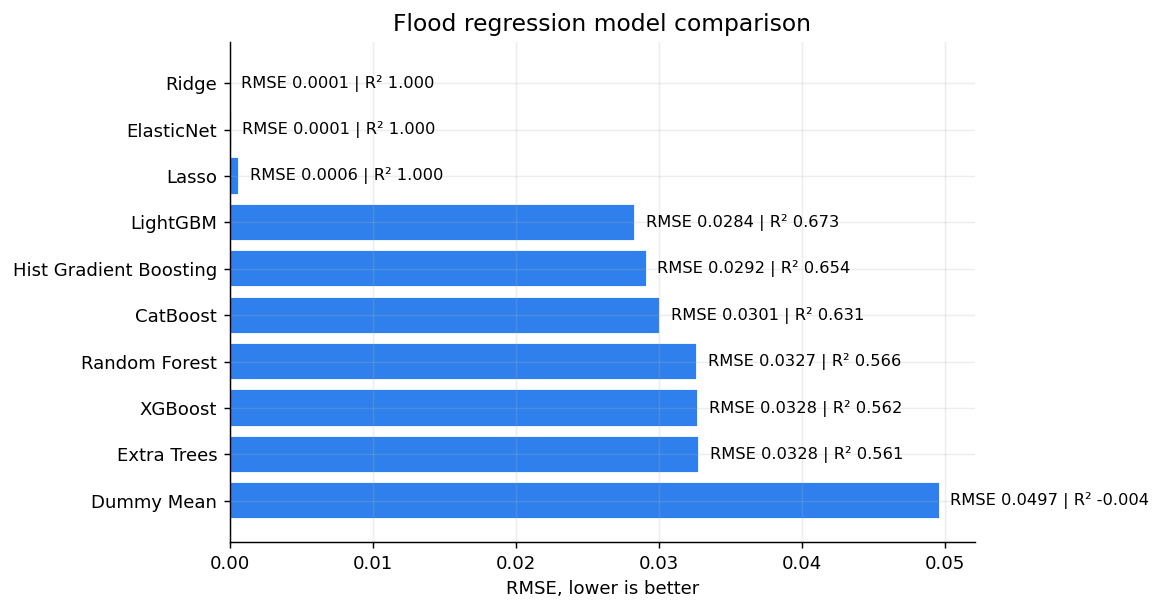

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_actual_vs_predicted.png


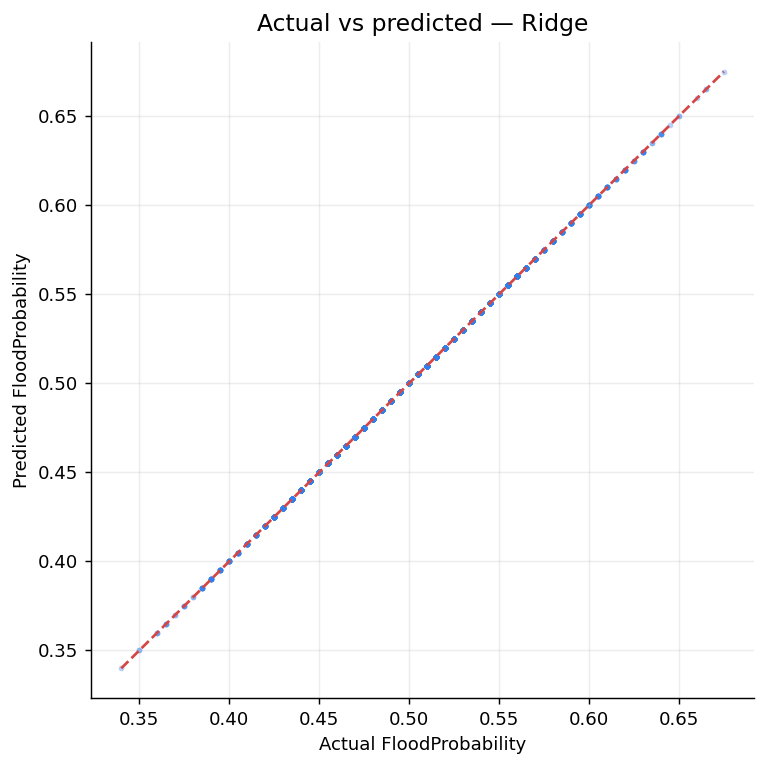

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_feature_importance.png


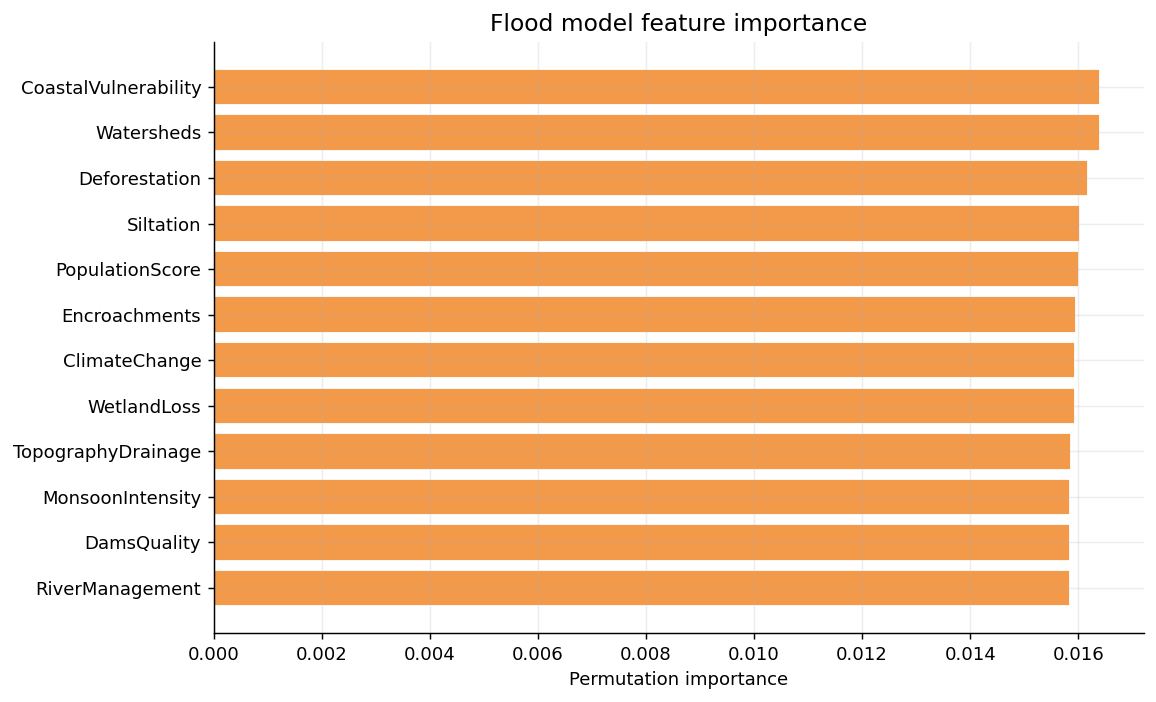

In [4]:
plot = reg_cv.sort_values('rmse_mean', ascending=True)
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(plot['model'], plot['rmse_mean'], color=COLORS['blue'], edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('RMSE, lower is better')
ax.set_title('Flood regression model comparison')
for b, r, r2 in zip(bars, plot['rmse_mean'], plot['r2_mean']):
    ax.text(r + plot['rmse_mean'].max()*0.015, b.get_y()+b.get_height()/2, f'RMSE {r:.4f} | R² {r2:.3f}', va='center', fontsize=9)
savefig('03_flood_regression_cv_ranking.png')
plt.show()

sample = pd.DataFrame({'actual': y_test, 'predicted': pred}).sample(min(2500, len(y_test)), random_state=42)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(sample['actual'], sample['predicted'], s=10, alpha=.35, color=COLORS['blue'], lw=0)
lo, hi = min(sample.min()), max(sample.max())
ax.plot([lo,hi],[lo,hi], ls='--', color=COLORS['red'])
ax.set_xlabel('Actual FloodProbability')
ax.set_ylabel('Predicted FloodProbability')
ax.set_title(f'Actual vs predicted — {best_reg_name}')
savefig('03_flood_actual_vs_predicted.png')
plt.show()

# Permutation importance on a sample for interpretability.
imp_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
imp_y = y_test.loc[imp_sample.index]
perm = permutation_importance(best_reg, imp_sample, imp_y, n_repeats=3, random_state=42, n_jobs=1, scoring='neg_root_mean_squared_error')
flood_imp = pd.DataFrame({'feature': FLOOD_FEATURES, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
flood_imp.to_csv(OUTPUT_DIR / '03_flood_feature_importance.csv', index=False)

top = flood_imp.head(12).sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top['feature'], top['importance'], color=COLORS['orange'], edgecolor='white')
ax.set_xlabel('Permutation importance')
ax.set_title('Flood model feature importance')
savefig('03_flood_feature_importance.png')
plt.show()

# Part B — Rice vulnerability classification

In [5]:
rice_model = rice_df[rice_df[RICE_TARGET].isin(LABEL_ORDER)].reset_index(drop=True)

policy_path = OUTPUT_DIR / '02_feature_modeling_policy.csv'
if policy_path.exists():
    feature_policy_df = pd.read_csv(policy_path)
    feature_policy_map = dict(zip(feature_policy_df['column'], feature_policy_df['modeling_policy']))
else:
    feature_policy_df = pd.DataFrame(columns=['column','modeling_policy'])
    feature_policy_map = {}

meta_audit_cols = set(metadata.get('audit_only_columns', []))
meta_admin_cols = set(metadata.get('admin_columns', []))
lf_cols = set(metadata.get('labeling_function_columns', []))
redundant_cols = set(metadata.get('redundant_operational_exclude_columns', [])) | {'rc_ratio'}

CLUSTER_AUDIT_COLS = meta_audit_cols | {c for c in rice_model.columns if 'cluster' in c.lower()}
SCORE_COLS = {c for c in rice_model.columns if c.endswith('_score')}
HARD_RULE_FLAGS = {'below_break_even_flag', 'negative_margin_flag'}
LABEL_FUNCTION_COLS = lf_cols | {c for c in rice_model.columns if c.startswith('lf_')}
ADMIN_AND_ID_COLS = meta_admin_cols | {'dmu', 'source_sheet', 'source_row', 'actor_role'}
TARGET_AND_TEXT_COLS = {RICE_TARGET, 'label_reason', 'label_source', 'labeling_function_hits'}

POLICY_EXCLUDE_STATUSES = {
    'target',
    'audit_only_excluded_from_modeling',
    'label_construction_excluded_from_operational',
    'identifier_or_admin_excluded_from_modeling',
    'redundant_inverse_excluded_from_operational',
}
POLICY_EXCLUDED_COLS = {c for c, status in feature_policy_map.items() if status in POLICY_EXCLUDE_STATUSES}

OPERATIONAL_EXCLUDE = (
    TARGET_AND_TEXT_COLS | ADMIN_AND_ID_COLS | CLUSTER_AUDIT_COLS |
    SCORE_COLS | HARD_RULE_FLAGS | LABEL_FUNCTION_COLS |
    POLICY_EXCLUDED_COLS | redundant_cols |
    {'final_vulnerability_score', 'rule_vulnerability_score'}
)

def valid_feature_list(cols):
    kept = []
    for c in cols:
        if c not in rice_model.columns:
            continue
        s = rice_model[c]
        if s.notna().sum() == 0:
            continue
        if s.nunique(dropna=True) <= 1:
            continue
        kept.append(c)
    return kept

operational_features = valid_feature_list([c for c in rice_model.columns if c not in OPERATIONAL_EXCLUDE])

forbidden_found = sorted(set(operational_features) & (
    CLUSTER_AUDIT_COLS | SCORE_COLS | HARD_RULE_FLAGS | LABEL_FUNCTION_COLS |
    {'final_vulnerability_score', 'rule_vulnerability_score', 'label_reason', 'label_source', 'labeling_function_hits'} |
    redundant_cols
))
assert not forbidden_found, f'Operational feature leakage detected: {forbidden_found}'

feature_audit = pd.DataFrame([{
    'mode': 'operational_prediction',
    'n_features': len(operational_features),
    'contains_cluster_feature': any('cluster' in c.lower() for c in operational_features),
    'contains_score_feature': any(c.endswith('_score') for c in operational_features),
    'contains_rc_ratio': 'rc_ratio' in operational_features,
    'example_features': ', '.join(operational_features[:15])
}])
display(feature_audit)

,mode,n_features,contains_cluster_feature,contains_score_feature,contains_rc_ratio,example_features
0,operational_prediction,34,False,False,False,"actor, region, total_cost, output_value, margi..."


In [6]:
def build_clf(Xf, model):
    cat = Xf.select_dtypes(include=['object','category']).columns.tolist()
    num = [c for c in Xf.columns if c not in cat]
    prep = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), num),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', make_onehot())]), cat)
    ], remainder='drop')
    return Pipeline([('prep', prep), ('model', model)])

# Complete classification model zoo. Boosters are optional but kept in Notebook 03.
classifiers = {
    'Dummy Most Frequent': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=120, max_depth=None, min_samples_leaf=3, class_weight='balanced_subsample', random_state=42, n_jobs=1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=140, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=1),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=80, learning_rate=.06, random_state=42),
}

if RUN_OPTIONAL_BOOSTERS and optional_import('xgboost'):
    from xgboost import XGBClassifier
    classifiers['XGBoost'] = LabelEncodedClassifier(XGBClassifier(
        n_estimators=70, max_depth=4, learning_rate=.05,
        subsample=.90, colsample_bytree=.90,
        objective='multi:softprob', eval_metric='mlogloss',
        random_state=42, n_jobs=1
    ))
if RUN_OPTIONAL_BOOSTERS and optional_import('lightgbm'):
    from lightgbm import LGBMClassifier
    classifiers['LightGBM'] = LGBMClassifier(
        n_estimators=80, learning_rate=.05, num_leaves=31,
        class_weight='balanced', random_state=42, n_jobs=1, verbose=-1
    )
if RUN_OPTIONAL_BOOSTERS and optional_import('catboost'):
    from catboost import CatBoostClassifier
    classifiers['CatBoost'] = LabelEncodedClassifier(CatBoostClassifier(
        iterations=80, learning_rate=.05, depth=6,
        loss_function='MultiClass', verbose=False, random_seed=42, thread_count=1
    ))

print('Rice classification candidates:', list(classifiers.keys()))

y_all = rice_model[RICE_TARGET]
train_idx, test_idx = train_test_split(rice_model.index, test_size=.25, random_state=42, stratify=y_all)
train_df = rice_model.loc[train_idx].reset_index(drop=True)
test_df = rice_model.loc[test_idx].reset_index(drop=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {'accuracy':'accuracy', 'balanced_accuracy':'balanced_accuracy', 'f1_macro':'f1_macro', 'f1_weighted':'f1_weighted'}

rows, pipes = [], {}
Xtr = train_df[operational_features]
ytr = train_df[RICE_TARGET]
for name, model in classifiers.items():
    pipe = build_clf(Xtr, model)
    scores = cross_validate(pipe, Xtr, ytr, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        'mode': 'operational_prediction',
        'model': name,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
        'balanced_accuracy_std': scores['test_balanced_accuracy'].std(),
        'f1_macro_mean': scores['test_f1_macro'].mean(),
        'f1_macro_std': scores['test_f1_macro'].std(),
        'f1_weighted_mean': scores['test_f1_weighted'].mean(),
        'f1_weighted_std': scores['test_f1_weighted'].std(),
        'n_features': len(operational_features),
        'is_optional_booster': name in {'XGBoost', 'LightGBM', 'CatBoost'}
    })
    pipes[name] = pipe

clf_cv = pd.DataFrame(rows)
clf_cv['selection_score'] = .70 * clf_cv['f1_macro_mean'] + .30 * clf_cv['balanced_accuracy_mean']
clf_cv = clf_cv.sort_values('selection_score', ascending=False).reset_index(drop=True)

best_clf_name = clf_cv.iloc[0]['model']
best_clf = pipes[best_clf_name]
best_clf.fit(train_df[operational_features], train_df[RICE_TARGET])
test_pred = best_clf.predict(test_df[operational_features])

rice_holdout = pd.DataFrame([{
    'mode': 'operational_prediction',
    'model': best_clf_name,
    'accuracy': accuracy_score(test_df[RICE_TARGET], test_pred),
    'balanced_accuracy': balanced_accuracy_score(test_df[RICE_TARGET], test_pred),
    'f1_macro': f1_score(test_df[RICE_TARGET], test_pred, average='macro'),
    'f1_weighted': f1_score(test_df[RICE_TARGET], test_pred, average='weighted'),
    'n_features': len(operational_features)
}])

display(clf_cv)
display(rice_holdout)
print(classification_report(test_df[RICE_TARGET], test_pred))

Rice classification candidates: ['Dummy Most Frequent', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']


,mode,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,n_features,is_optional_booster,selection_score
0,operational_prediction,Decision Tree,0.994924,0.004145,0.995796,0.003207,0.987573,0.010104,0.995039,0.004028,34,False,0.990040
1,operational_prediction,Random Forest,0.994924,0.004145,0.990462,0.011466,0.987673,0.010104,0.994945,0.004148,34,False,0.988509
2,operational_prediction,CatBoost,0.994924,0.004145,0.989999,0.010907,0.987121,0.010659,0.994946,0.004142,34,True,0.987985
3,operational_prediction,Hist Gradient Boosting,0.993232,0.006331,0.988389,0.013154,0.983275,0.015650,0.993327,0.006235,34,False,0.984809
4,operational_prediction,XGBoost,0.989848,0.010966,0.980625,0.024065,0.974819,0.027234,0.989994,0.010799,34,True,0.976561
5,operational_prediction,LightGBM,0.989848,0.010966,0.972947,0.034899,0.973257,0.029406,0.989718,0.011183,34,True,0.973164
6,operational_prediction,Extra Trees,0.925377,0.025509,0.877577,0.019615,0.856481,0.036376,0.929059,0.022850,34,False,0.862810
7,operational_prediction,Logistic Regression,0.569529,0.052177,0.579620,0.042314,0.526800,0.032530,0.639618,0.040417,34,False,0.542646
8,operational_prediction,Dummy Most Frequent,0.571187,0.002079,0.333333,0.000000,0.242358,0.000562,0.415299,0.002474,34,False,0.269651


,mode,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,n_features
0,operational_prediction,Decision Tree,0.984772,0.969363,0.963253,0.984938,34


                      precision    recall  f1-score   support

  High Vulnerability       1.00      0.97      0.99        68
   Low Vulnerability       0.99      1.00      1.00       113
Medium Vulnerability       0.88      0.94      0.91        16

            accuracy                           0.98       197
           macro avg       0.96      0.97      0.96       197
        weighted avg       0.99      0.98      0.98       197



saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_classification_cv_comparison.png


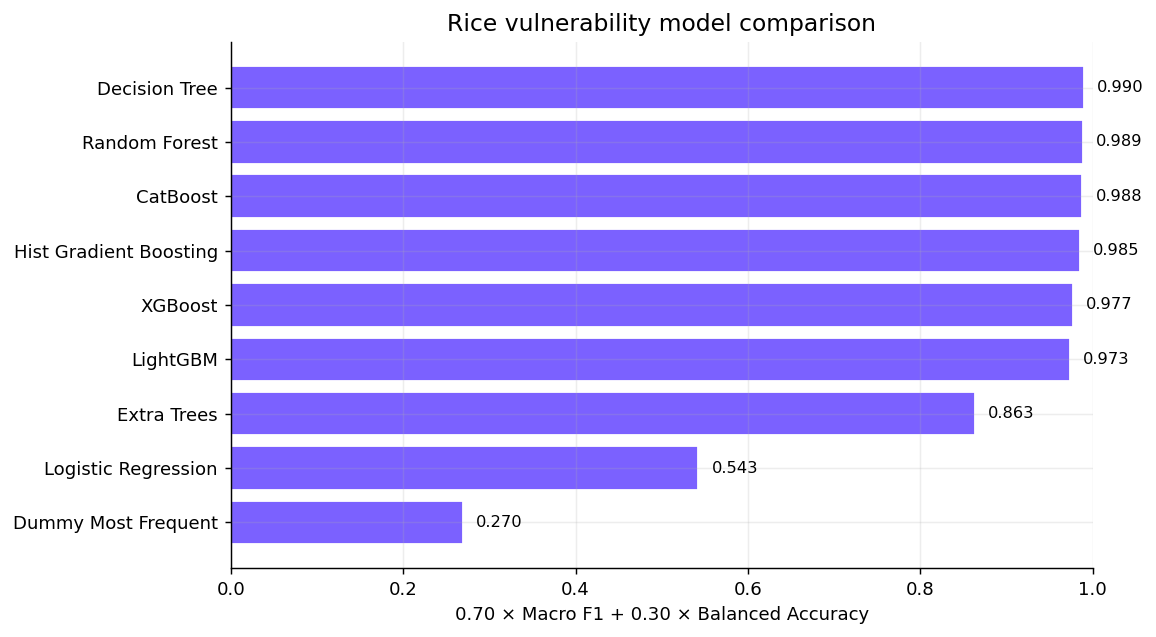

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_operational_confusion_matrix.png


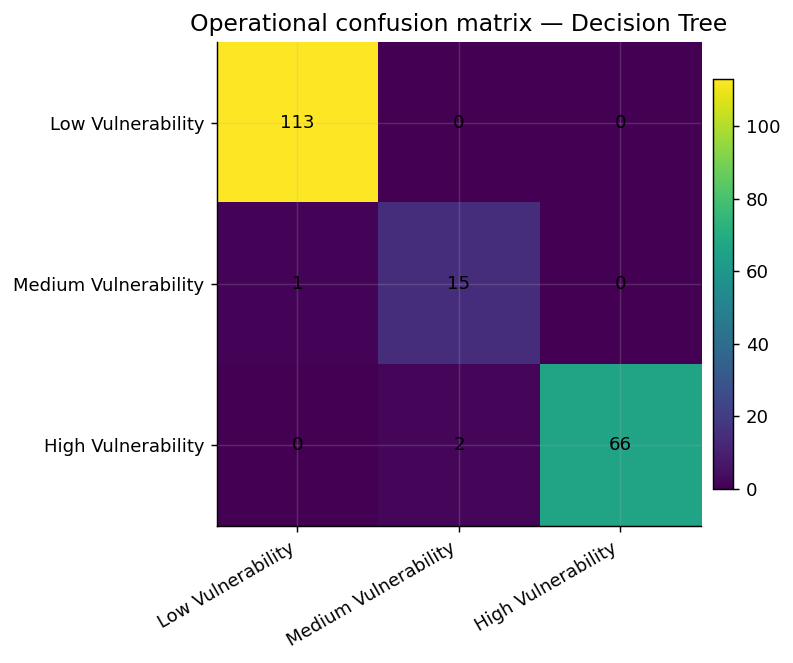

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_feature_importance.png


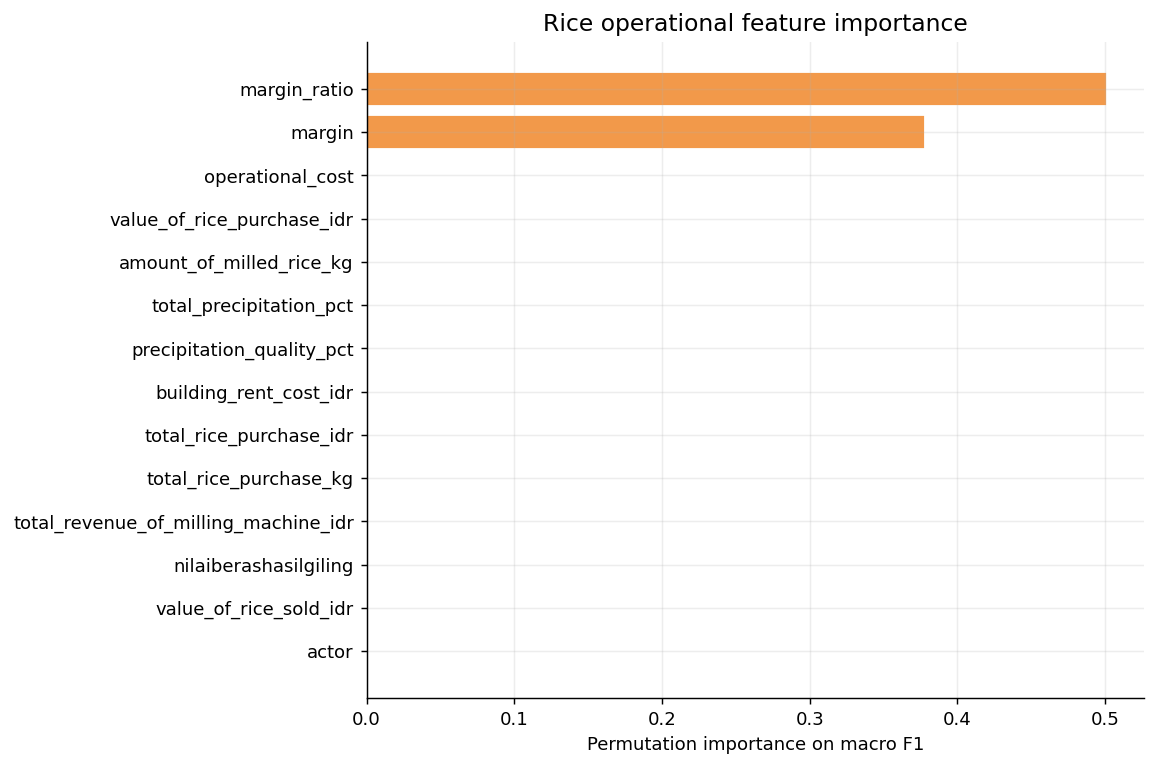

In [7]:
plot = clf_cv.sort_values('selection_score', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot['model'], plot['selection_score'], color=COLORS['purple'], edgecolor='white')
ax.set_xlim(0, 1)
ax.set_xlabel('0.70 × Macro F1 + 0.30 × Balanced Accuracy')
ax.set_title('Rice vulnerability model comparison')
for b, v in zip(bars, plot['selection_score']):
    ax.text(v + 0.015, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
savefig('03_rice_classification_cv_comparison.png')
plt.show()

cm = confusion_matrix(test_df[RICE_TARGET], test_pred, labels=LABEL_ORDER)
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(cm)
ax.set_xticks(range(len(LABEL_ORDER))); ax.set_xticklabels(LABEL_ORDER, rotation=30, ha='right')
ax.set_yticks(range(len(LABEL_ORDER))); ax.set_yticklabels(LABEL_ORDER)
ax.set_title(f'Operational confusion matrix — {best_clf_name}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=.035, pad=.02)
savefig('03_rice_operational_confusion_matrix.png')
plt.show()

perm = permutation_importance(
    best_clf, test_df[operational_features], test_df[RICE_TARGET],
    n_repeats=10, random_state=42, n_jobs=1, scoring='f1_macro'
)
rice_imp = pd.DataFrame({'feature': operational_features, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
rice_imp.to_csv(OUTPUT_DIR / '03_rice_feature_importance.csv', index=False)

top = rice_imp.head(14).sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['feature'], top['importance'], color=COLORS['orange'], edgecolor='white')
ax.set_xlabel('Permutation importance on macro F1')
ax.set_title('Rice operational feature importance')
savefig('03_rice_feature_importance.png')
plt.show()

## 2C. Model selection rationale and error analysis

Notebook 03 is now **modelling-only**, but it still needs to explain why selected models are used and whether errors are concentrated in specific actor or region groups. This protects the analysis from being only a metric table and keeps the modelling tied to the business problem.

,task,selected_model,selection_metric,holdout_summary,main_caution
0,FloodProbability regression,Ridge,"Lowest CV RMSE, checked on holdout RMSE/R2",RMSE=0.00000; R2=1.00000,Flood dataset target is tabular and may be str...
1,Rice vulnerability classification,Decision Tree,0.70 × Macro F1 + 0.30 × Balanced Accuracy,MacroF1=0.96325; BalancedAcc=0.96936,"Target is a paper-grounded pseudo-label, not e..."


,actor,n_holdout,error_rate
0,Farmer,95,0.031579
1,Middlemen,30,0.000000
2,Retail,25,0.000000
3,Rice Miller,27,0.000000
4,Wholesaler,20,0.000000


,region,n_holdout,error_rate
1,Indramayu,35,0.028571
0,Garut,47,0.021277
4,Tasikmalaya,50,0.020000
2,Karawang,29,0.000000
3,Subang,36,0.000000


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_error_by_actor.png


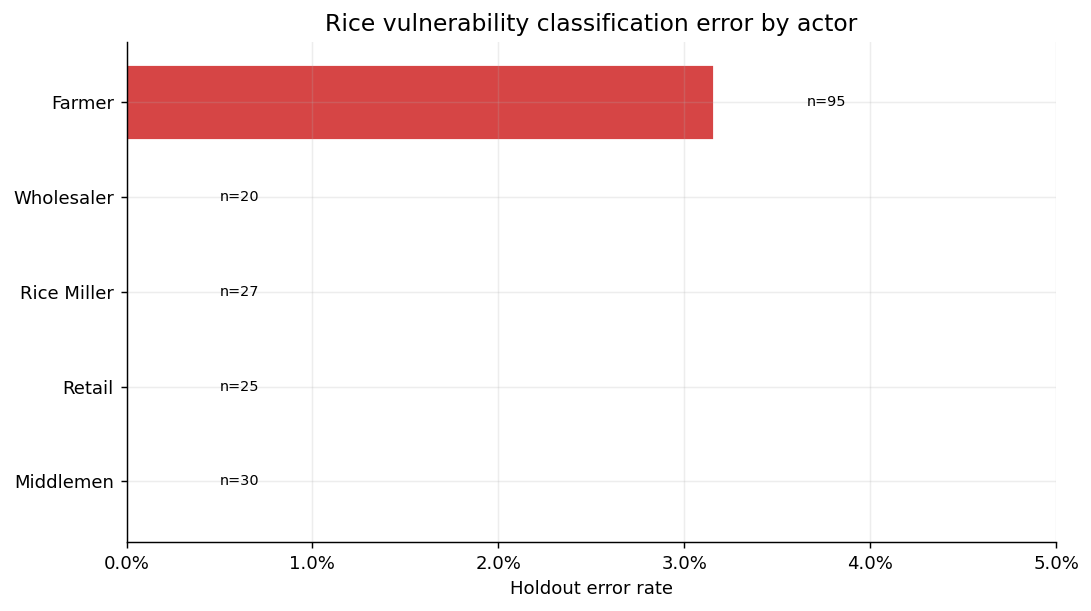

,actor,region,vulnerability_label,predicted_vulnerability_label,cost_revenue_ratio,margin,operational_burden_ratio,label_reason
0,Farmer,Garut,High Vulnerability,Medium Vulnerability,0.984597,126000.0,0.700489,Thin R/C buffer; Thin margin buffer; Far from ...
1,Farmer,Indramayu,High Vulnerability,Medium Vulnerability,0.987786,80000.0,0.746565,Thin R/C buffer; Thin margin buffer; Far from ...
2,Farmer,Tasikmalaya,Medium Vulnerability,Low Vulnerability,0.864086,1949000.0,0.620990,Far from actor frontier


In [8]:
# Model selection rationale.
model_selection_rationale = pd.DataFrame([
    {
        'task': 'FloodProbability regression',
        'selected_model': best_reg_name,
        'selection_metric': 'Lowest CV RMSE, checked on holdout RMSE/R2',
        'holdout_summary': f"RMSE={float(flood_holdout['rmse'].iloc[0]):.5f}; R2={float(flood_holdout['r2'].iloc[0]):.5f}",
        'main_caution': 'Flood dataset target is tabular and may be strongly formula-like; interpret feature importance with caution.'
    },
    {
        'task': 'Rice vulnerability classification',
        'selected_model': best_clf_name,
        'selection_metric': '0.70 × Macro F1 + 0.30 × Balanced Accuracy',
        'holdout_summary': f"MacroF1={float(rice_holdout['f1_macro'].iloc[0]):.5f}; BalancedAcc={float(rice_holdout['balanced_accuracy'].iloc[0]):.5f}",
        'main_caution': 'Target is a paper-grounded pseudo-label, not external field ground truth.'
    }
])
model_selection_rationale.to_csv(OUTPUT_DIR / '03_model_selection_rationale.csv', index=False)
display(model_selection_rationale)

# Build audit dataframe for rice holdout prediction errors.
holdout_audit_cols = [
    'actor', 'region', 'dmu', RICE_TARGET, 'label_reason',
    'total_cost', 'output_value', 'margin', 'cost_revenue_ratio',
    'operational_burden_ratio', 'margin_ratio'
]
holdout_audit_cols = [c for c in holdout_audit_cols if c in test_df.columns]
error_audit = test_df[holdout_audit_cols].copy()
error_audit['predicted_vulnerability_label'] = test_pred
error_audit['is_error'] = error_audit[RICE_TARGET].ne(error_audit['predicted_vulnerability_label'])
error_audit.to_csv(OUTPUT_DIR / '03_rice_holdout_prediction_audit.csv', index=False)

# Error rate by actor and region.
error_by_actor = (
    error_audit.groupby('actor', dropna=False)
    .agg(n_holdout=('actor', 'size'), error_rate=('is_error', 'mean'))
    .reset_index()
    .sort_values('error_rate', ascending=False)
)
error_by_region = (
    error_audit.groupby('region', dropna=False)
    .agg(n_holdout=('region', 'size'), error_rate=('is_error', 'mean'))
    .reset_index()
    .sort_values('error_rate', ascending=False)
)
error_by_actor.to_csv(OUTPUT_DIR / '03_rice_error_by_actor.csv', index=False)
error_by_region.to_csv(OUTPUT_DIR / '03_rice_error_by_region.csv', index=False)
display(error_by_actor)
display(error_by_region)

# Focused visual: actor-level error concentration.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_err = error_by_actor.sort_values('error_rate')
bars = ax.barh(plot_err['actor'], plot_err['error_rate'], color=COLORS['red'], edgecolor='white')
ax.set_xlim(0, max(0.05, plot_err['error_rate'].max() * 1.25))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Holdout error rate')
ax.set_title('Rice vulnerability classification error by actor')
for b, n in zip(bars, plot_err['n_holdout']):
    ax.text(b.get_width() + 0.005, b.get_y() + b.get_height()/2, f'n={int(n)}', va='center', fontsize=8)
savefig('03_rice_error_by_actor.png')
plt.show()

# Top disagreement examples for audit.
disagreement_cols = [
    'actor', 'region', RICE_TARGET, 'predicted_vulnerability_label',
    'cost_revenue_ratio', 'margin', 'operational_burden_ratio', 'label_reason'
]
disagreement_cols = [c for c in disagreement_cols if c in error_audit.columns]
disagreements = error_audit[error_audit['is_error']].copy()
if not disagreements.empty:
    disagreements = disagreements.sort_values(['actor', 'region']).reset_index(drop=True)
    disagreements[disagreement_cols].head(30).to_csv(OUTPUT_DIR / '03_rice_prediction_disagreements_top30.csv', index=False)
    display(disagreements[disagreement_cols].head(30))
else:
    pd.DataFrame(columns=disagreement_cols).to_csv(OUTPUT_DIR / '03_rice_prediction_disagreements_top30.csv', index=False)
    print('No holdout disagreements found for the selected rice model.')

## 3. Export final models and transition files

In [9]:
# Final artifacts use the fitted holdout-selected models to keep runtime stable.
# They are sufficient for transition predictions used by Notebook 04 and 05.
final_flood = best_reg
joblib.dump(final_flood, MODEL_DIR / '03_final_flood_probability_model.joblib')

final_rice = best_clf
joblib.dump(final_rice, MODEL_DIR / '03_final_rice_vulnerability_model.joblib')

# Flood full predictions.
flood_full = flood_df.copy()
flood_full['predicted_FloodProbability'] = np.clip(final_flood.predict(flood_df[FLOOD_FEATURES]), 0, 1)
q33, q66 = flood_full['predicted_FloodProbability'].quantile([1/3, 2/3])
flood_full['predicted_flood_risk_level'] = pd.cut(
    flood_full['predicted_FloodProbability'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Low', 'Medium', 'High']
).astype(str)
flood_full.to_csv(OUTPUT_DIR / '03_flood_full_predictions.csv', index=False)

flood_scenario_summary = (
    flood_full.groupby('predicted_flood_risk_level')
    .agg(
        n_scenarios=('predicted_FloodProbability', 'size'),
        min_predicted_probability=('predicted_FloodProbability', 'min'),
        median_predicted_probability=('predicted_FloodProbability', 'median'),
        max_predicted_probability=('predicted_FloodProbability', 'max')
    )
    .reset_index()
    .rename(columns={'predicted_flood_risk_level':'flood_scenario'})
)
flood_scenario_summary.to_csv(OUTPUT_DIR / '03_flood_scenario_summary.csv', index=False)

# Rice full predictions and probabilities.
transition_cols = [
    'actor', 'region', 'dmu', RICE_TARGET, 'label_reason',
    'total_cost', 'output_value', 'margin',
    'cost_revenue_ratio', 'operational_burden_ratio', 'margin_ratio',
    'operational_cost', 'quantity_proxy',
    'precipitation_quality_pct', 'total_precipitation_pct',
    'final_vulnerability_score'
]
transition_cols = [c for c in transition_cols if c in rice_model.columns]
rice_full = rice_model[transition_cols].copy()
rice_full['predicted_vulnerability_label'] = final_rice.predict(rice_model[operational_features])

if hasattr(final_rice, 'predict_proba'):
    proba = final_rice.predict_proba(rice_model[operational_features])
    for idx, cls in enumerate(final_rice.classes_):
        safe_cls = str(cls).lower().replace(' ', '_').replace('/', '_')
        rice_full[f'predicted_proba_{safe_cls}'] = proba[:, idx]

rice_full.to_csv(OUTPUT_DIR / '03_rice_full_predictions.csv', index=False)

# Actor-region summary for stress test and decision support.
agg_spec = {'n_units': ('actor', 'size')}
for col, alias in [
    ('total_cost', 'median_total_cost'),
    ('output_value', 'median_revenue'),
    ('margin', 'median_margin'),
    ('cost_revenue_ratio', 'median_cost_revenue_ratio'),
    ('operational_burden_ratio', 'median_operational_burden_ratio'),
    ('margin_ratio', 'median_margin_ratio'),
    ('final_vulnerability_score', 'median_vulnerability_score')
]:
    if col in rice_full.columns:
        agg_spec[alias] = (col, 'median')

actor_region_summary = rice_full.groupby(['region', 'actor'], dropna=False).agg(**agg_spec).reset_index()
actor_region_summary['dominant_true_vulnerability_label'] = rice_full.groupby(['region','actor'])[RICE_TARGET].apply(mode_or_unknown).values
actor_region_summary['dominant_predicted_vulnerability_label'] = rice_full.groupby(['region','actor'])['predicted_vulnerability_label'].apply(mode_or_unknown).values
actor_region_summary['predicted_high_vulnerability_share'] = (
    rice_full.assign(_high=rice_full['predicted_vulnerability_label'].eq('High Vulnerability').astype(float))
    .groupby(['region','actor'])['_high'].mean().values
)
actor_region_summary['true_high_vulnerability_share'] = (
    rice_full.assign(_high=rice_full[RICE_TARGET].eq('High Vulnerability').astype(float))
    .groupby(['region','actor'])['_high'].mean().values
)
if 'predicted_proba_high_vulnerability' in rice_full.columns:
    actor_region_summary['median_predicted_proba_high'] = rice_full.groupby(['region','actor'])['predicted_proba_high_vulnerability'].median().values

actor_region_summary.to_csv(OUTPUT_DIR / '03_actor_region_model_summary.csv', index=False)

# Metrics and artifacts.
reg_cv.to_csv(OUTPUT_DIR / '03_flood_cv_results.csv', index=False)
flood_holdout.to_csv(OUTPUT_DIR / '03_flood_holdout_metrics.csv', index=False)
clf_cv.to_csv(OUTPUT_DIR / '03_rice_cv_results.csv', index=False)
rice_holdout.to_csv(OUTPUT_DIR / '03_rice_holdout_metrics.csv', index=False)
pd.DataFrame({'operational_feature': operational_features}).to_csv(OUTPUT_DIR / '03_operational_feature_list.csv', index=False)
pd.DataFrame({'excluded_from_operational': sorted([c for c in OPERATIONAL_EXCLUDE if c in rice_model.columns])}).to_csv(OUTPUT_DIR / '03_operational_excluded_features.csv', index=False)

summary = {
    'best_flood_regression_model': best_reg_name,
    'flood_regression_candidates': list(regressors.keys()),
    'best_rice_operational_model': best_clf_name,
    'rice_classification_candidates': list(classifiers.keys()),
    'flood_holdout': flood_holdout.to_dict('records')[0],
    'rice_operational_holdout': rice_holdout.to_dict('records')[0],
    'rice_operational_n_features': len(operational_features),
    'rice_operational_uses_cluster_features': any('cluster' in c.lower() for c in operational_features),
    'rice_operational_uses_score_features': any(c.endswith('_score') for c in operational_features),
    'notebook_scope': 'model_training_only',
    'boosting_models_retained_in_notebook_03': True,
    'transition_outputs': [
        '03_flood_full_predictions.csv',
        '03_flood_scenario_summary.csv',
        '03_rice_full_predictions.csv',
        '03_actor_region_model_summary.csv'
    ],
    'next_notebooks': {
        '04': 'Method 5 stress-test sensitivity analysis',
        '05': 'Method 1 hazard-vulnerability decision support'
    }
}
json.dump(summary, open(OUTPUT_DIR / '03_final_model_summary.json', 'w'), indent=2)
json.dump(summary, open(OUTPUT_DIR / '03_model_transition_manifest.json', 'w'), indent=2)

print(json.dumps(summary, indent=2))
print('Saved transition outputs:')
for p in summary['transition_outputs']:
    print('-', p, (OUTPUT_DIR / p).exists())

{
  "best_flood_regression_model": "Ridge",
  "flood_regression_candidates": [
    "Dummy Mean",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "Random Forest",
    "Extra Trees",
    "Hist Gradient Boosting",
    "XGBoost",
    "LightGBM",
    "CatBoost"
  ],
  "best_rice_operational_model": "Decision Tree",
  "rice_classification_candidates": [
    "Dummy Most Frequent",
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Hist Gradient Boosting",
    "XGBoost",
    "LightGBM",
    "CatBoost"
  ],
  "flood_holdout": {
    "model": "Ridge",
    "mae": 1.790161049403377e-06,
    "rmse": 2.2428357943190447e-06,
    "r2": 0.9999999979802693
  },
  "rice_operational_holdout": {
    "mode": "operational_prediction",
    "model": "Decision Tree",
    "accuracy": 0.9847715736040609,
    "balanced_accuracy": 0.9693627450980392,
    "f1_macro": 0.9632534165376562,
    "f1_weighted": 0.9849377249517359,
    "n_features": 34
  },
  "rice_operational_n_fea